#   Step 1: Install & Import Required Libraries

In [56]:
# Install SQLite3 (Comes Built in with Python)
import sqlite3

# Install Pandas for data analysis
import pandas as pd

# Insatll Seaborn & Matplotlib for visualization 
import matplotlib.pyplot as plt

import seaborn as sns

# This method hides any warnings in Jupyter Notebook
import warnings 
warnings.filterwarnings("ignore")

#  Step 2: Create a new SQLite Database and Table

In [80]:
# Connect to sqlite database(creates a new file if it doesn't exist)
conn = sqlite3.connect ("Customers_data.db")

#create a cursor to interact with the database 
cursor = conn.cursor()

#create a sample table
cursor.execute(""" 

CREATE TABLE IF NOT EXISTS CUSTOMERS (
Id INTEGER PRIMARY KEY AUTOINCREMENT,
Name TEXT,
Age INTEGER,
City TEXT,
Total_spent REAL)

""")

#Commit and close connection 
conn.commit()


# Strep 3: Insert Sample Data Into The The SQL Table

In [40]:
# Sample Data to Insert 
Customers = [

    ("Ankit Pandey", 23,"GHAZIABAD",500),
    ("Rahul", 22,"LUCKNOW",800),
    ("Aman Kumar", 28,"AARAH",1000),
    ("Kunal", 22,"GHAZIABAD",300),
    ("sachin",23,"NOIDA",1200),
    ("Ashish Pandey", 20,"GHAZIABAD",700),
    ("Aaditya Chaubey", 20,"GHAZIABAD",2000),
    ("Umesh Gautam", 23,"GHAZIABAD",1500)
]

# Insert Data into Table
cursor.executemany("INSERT INTO Customers (Name , Age , City , Total_spent) VALUES (? , ? , ? , ?)",Customers)

#Commit Changes
conn.commit()

    
    

# Step 4: Run  SQL Queries Inside JUPYTER NOTEBOOK 

In [42]:
#Run a SQL Query to retrieve all Customers Data

query = "select*from Customers"

df = pd.read_sql(query,conn) # to store query results in a pandas DataFrame

# Display the data
df.head()

,Id,Name,Age,City,Total_spent
0,1,Ankit Pandey,23,GHAZIABAD,500.0
1,2,Rahul,22,LUCKNOW,800.0
2,3,Aman Kumar,28,AARAH,1000.0
3,4,Kunal,22,GHAZIABAD,300.0
4,5,sachin,23,NOIDA,1200.0


# Step 5: Perform Data Analysis using SQL Queries

In [62]:
query = "select*from Customers Where Total_spent >=500"

pd.read_sql(query, conn) 

,Id,Name,Age,City,Total_spent
0,1,Ankit Pandey,23,GHAZIABAD,500.0
1,2,Rahul,22,LUCKNOW,800.0
2,3,Aman Kumar,28,AARAH,1000.0
3,5,sachin,23,NOIDA,1200.0
4,6,Ashish Pandey,20,GHAZIABAD,700.0
5,7,Aaditya Chaubey,20,GHAZIABAD,2000.0
6,8,Umesh Gautam,23,GHAZIABAD,1500.0
7,9,Ankit Pandey,23,GHAZIABAD,500.0
8,10,Rahul,22,LUCKNOW,800.0
9,11,Aman Kumar,28,AARAH,1000.0


In [66]:
#find the average customers age 

query = "select Avg(Age) as Average_Age from Customers"
pd.read_sql(query, conn)

,Average_Age
0,22.625


In [68]:
# Count Customers in each city 
query = "select City, COUNT(*) AS Num_Customers from Customers group by City"
pd.read_sql(query, conn)

,City,Num_Customers
0,AARAH,3
1,GHAZIABAD,15
2,LUCKNOW,3
3,NOIDA,3


# Step 6: Visualising SQL Query Results Using Pythonn


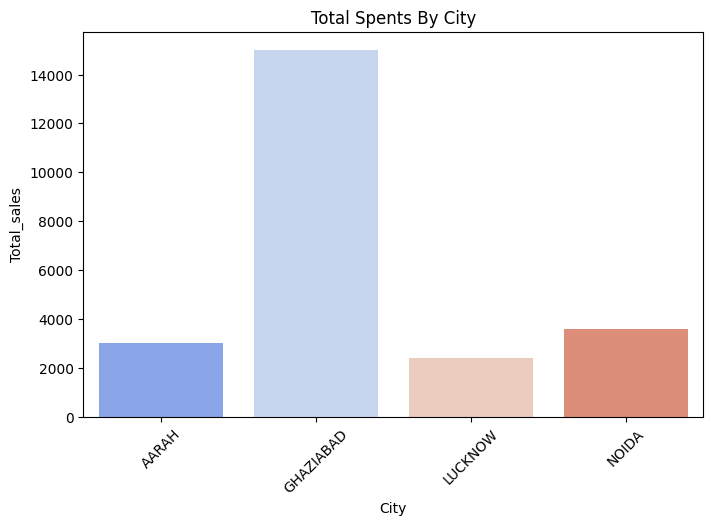

In [81]:
# Run SQL Query & Store Results in DataFrame

query = "select City, SUM(Total_spent) AS Total_sales from Customers Group by City"

df_sales = pd.read_sql(query, conn)

#plot the data
plt.figure(figsize = (8,5))
sns.barplot(x = "City", y = "Total_sales" ,data =df_sales, palette = "coolwarm")
plt.xticks(rotation = 45)
plt. title("Total Spents By City")
plt.show()

In [82]:
# Step 7: Close the SQL Connection
conn.close()